In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/creditcardfraud/creditcard.csv


# Unsupervised Fraud Detection using Gaussian Mixture Model

This notebook demonstrates how to use a **Gaussian Mixture Model (GMM)** — which applies **Bayes’ theorem internally** — to score and flag potentially fraudulent transactions in an **unsupervised** way (no labels used in training).  
We’ll use the Kaggle Credit Card Fraud dataset as an example.

## 1. Load and Preview the Data

We load the **Kaggle Credit Card Fraud dataset** and take a quick look at its shape and columns.


In [2]:
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture


# --- CONFIG--------

df = pd.read_csv("/kaggle/input/creditcardfraud/creditcard.csv")
n_components = 3    # No. of mixture components
random_state = 42   
top_percent_flag = 2    # flag top 2% most anomalous
#------------

# 1. Data Exploration
print("Data Shape: ", df.shape)
print("columns:", df.columns.tolist())


Data Shape:  (284807, 31)
columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


## 2. Prepare Data for Unsupervised Modelling
We drop the label column (`Class`) so that the model doesn’t see the fraud labels.  
We’ll keep it aside only for evaluation later.

In [3]:
labels = df['Class']
X = df.drop(columns=['Class']).values

print(df.head())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

## 3. Fit Gaussian Mixture Model (GMM)
We fit a GMM with `n_components` latent clusters.  
The model estimates priors and likelihoods for each cluster and, using Bayes’ theorem, computes **posterior probabilities** \(P(C_k|x)\) for every transaction.

---
## 4. Compute Anomaly Score
We compute the **log-likelihood** of each transaction under the mixture model.  
The **anomaly score** is defined as the negative log-likelihood (low likelihood → high anomaly).  


In [4]:
# Fit GMM
Gmm = GaussianMixture(n_components=n_components, covariance_type='full', random_state=random_state)
Gmm.fit(X)

# Compute the likelihood per sample 
log_likelihood = Gmm.score_samples(X)
anomaly_score = -log_likelihood   # lower likelihood = higher anomaly score


## 5. Save Data to CSV 
We flag the top N% highest anomaly scores as “potential fraud” and Save results in `creditcard_with_anomaly_scores.csv`.

In [5]:
threshold = np.percentile(anomaly_score, 100 - top_percent_flag)
flags = anomaly_score >= threshold

# Save Results
df_out = df.copy()
df_out['anomaly_score'] = anomaly_score
df_out['flagged'] = flags.astype(int)
df_out.to_csv("creditcard_with_anomaly_scores.csv", index=False)
print("Saved output with anomaly score to creditcard_with_anomaly_scores.csv")

Saved output with anomaly score to creditcard_with_anomaly_scores.csv


## 6. Visualize Anomaly Scores
Plot a histogram of anomaly scores and, for 2D data, a scatter plot coloured by the anomaly score to see how points separate.


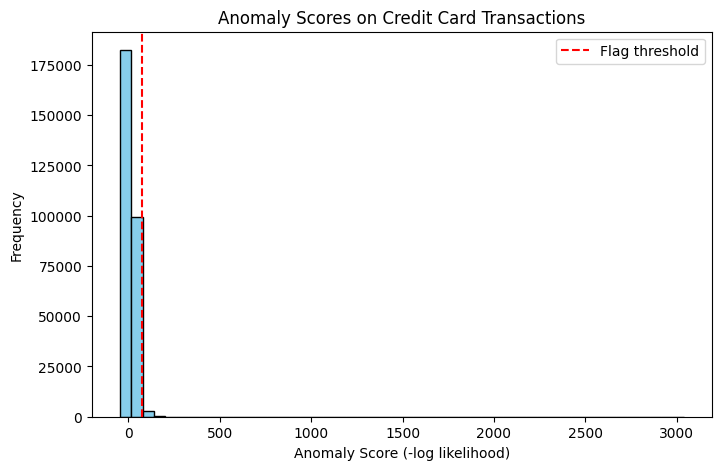

In [6]:
# Visualization of anomaly scores

plt.figure(figsize=(8,5))
plt.hist(anomaly_score, bins=50, color='skyblue', edgecolor='black')
plt.axvline(threshold, color='red', linestyle='--', label='Flag threshold')
plt.xlabel('Anomaly Score (-log likelihood)')
plt.ylabel('Frequency')
plt.title('Anomaly Scores on Credit Card Transactions')
plt.legend()
plt.show()

## 7. Evaluate Against True Labels

Using the real `Class` labels we held back, we compute:
- Confusion matrix (TP, FP, FN, TN)
- Precision, Recall, F1-score
- ROC–AUC using the continuous anomaly score  
This shows how well our unsupervised model actually detects fraud.


Confusion Matrix: 
[[278969   5346]
 [   141    351]]
TN=278969, FP=5346, FN=141, TP=351
Precision: 0.062
Recall: 0.713
F1 Score: 0.113
ROC AUC (anomaly score): 0.928


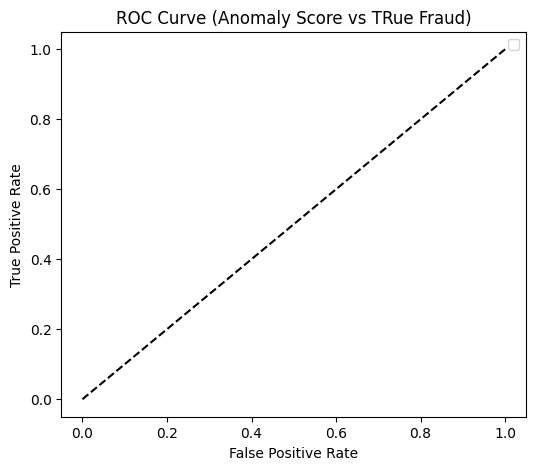

In [7]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score, roc_curve


y_true = labels.values
y_pred = flags.astype(int)
y_score = anomaly_score     # higher = more anomalous

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()
print("Confusion Matrix: ")
print(cm)
print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")

# Precision, Recall, F1
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
print(f"Precision: {precision:.3f}\nRecall: {recall:.3f}\nF1 Score: {f1:.3f}")

# ROC AUC using continous anomaly score
auc = roc_auc_score(y_true, y_score)
print(f"ROC AUC (anomaly score): {auc:.3f}")

# Plot ROC Curve
fpr, tpr, thresholds = roc_curve(y_true, y_score)
plt.figure(figsize=(6,5))
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Anomaly Score vs TRue Fraud)')
plt.legend()
plt.show()

## Conclusion / Takeaways

In this notebook, an unsupervised Gaussian Mixture Model was applied to the Kaggle credit-card transactions dataset.  
The model estimates priors and Gaussian likelihoods for hidden clusters and, using Bayes’ theorem, computes posterior probabilities for each transaction.  
We turned those posteriors into an anomaly score (−log likelihood) and flagged the top 2 % as potential fraud.  
At that threshold, we achieved ~71 % recall on fraudulent transactions with an ROC-AUC of ~0.93, showing that the score can rank frauds well even without labels.  
**Changing the threshold lets us trade precision for recall, which is a key consideration in real-world fraud detection.**